# Assignment 6 - MOEA Convergence & Reference Set Construction

**Course:** EPA141A Model-Based Decision Making - Delft University of Technology  
**Model:** JUSTICE  

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Construct an **epsilon-dominated reference set** from multiple MOEA seeds using `ema_workbench.em_framework.optimization.epsilon_nondominated`.
2. Compute and interpret **hypervolume**, **epsilon-progress**, **generational distance**, and **epsilon indicator** as MOEA quality indicators.
3. Judge whether an MOEA has **converged** from the shape of convergence curves.

---

## Background

### Convergence vs. quality

Two separate questions must be answered before trusting MOEA results:

| Question | Metric | Good sign |
|----------|--------|-----------|
| Did the algorithm **converge**? | Epsilon-progress, hypervolume over NFE | Plateau reached well before NFE is exhausted |
| Is the Pareto front **good**? | Hypervolume, GD, epsilon indicator | High HV, low GD, low EI |


---

## Overview

This assignment analyses the results from Assignment 5. You will:

1. **Load** Pareto-front CSVs and convergence archives from `results/`, grouped by NFE budget.
2. **Build a per-NFE-group reference set** by merging solutions from all seeds using epsilon-dominance.
3. **Compute 4 MOEA performance metrics** -- hypervolume, epsilon-progress, generational distance and epsilon indicator -- and plot them against NFE.

## Setup — Imports and model configuration

The cell below imports all required packages, applies a Python 3.14 compatibility patch for `matplotlib.path.Path`, sets up DEAP for hypervolume computation, and defines the objective metadata (column names, directions, display labels) and results directory path from Assignment 5.

In [1]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# Matplotlib deepcopy patch (Python 3.14 + matplotlib compatibility)
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Hypervolume — moocore (DEAP 1.4 dropped the private deap.tools._hypervolume submodule)
import moocore

#  Archive loader — handles ema_workbench 2.x and 3.0 archive formats.
import tarfile as _tarfile
import io as _io

def load_archives(path_to_file):
    """Load convergence archives (handles both ema_workbench 2.x and 3.0 formats).
    
    New format (3.0): plain tar, files at root level (0.csv, 502.csv...)
    Both: r:* auto-detects compression; NFE extracted from basename stem.
    """
    archives = []
    import pandas as _pd
    with _tarfile.open(path_to_file, "r:*") as archive:
        for fn in archive.getnames():
            f = archive.extractfile(fn)
            if f is None:
                continue  # skip directory entries
            basename = fn.split("/")[-1]
            try:
                nfe = int(basename.split(".")[0])
            except ValueError:
                continue
            data = _pd.read_csv(f)
            archives.append((nfe, data))
    return archives

# Path setup
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)

# Anchor RESULTS_ROOT to _JUSTICE_ROOT so it always resolves to
# <repo>/assignments_ema/results regardless of the notebook's launch CWD.
RESULTS_ROOT = os.path.normpath(os.path.join(_JUSTICE_ROOT, "..", "assignments_ema", "results_big"))

# Objective metadata
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

# Hypervolume helpers — moocore handles mixed min/max via the `maximise` mask,
# so points and reference point stay in original coordinates.
_MAXIMISE_MASK = [col in MAXIMIZE_COLS for col in OBJECTIVE_COLS]

def _compute_hypervolume(archive_df, ref_point):
    """Hypervolume via moocore. ref_point must be strictly worse than every
    point on every axis (worse = larger for MIN axes, smaller for MAX axes)."""
    pts = archive_df[OBJECTIVE_COLS].to_numpy()
    return moocore.hypervolume(pts, ref=ref_point, maximise=_MAXIMISE_MASK)

def _compute_ref_point(ref_df, margin=0.1):
    """Reference point in original coordinates, padded outward on every axis."""
    rp = []
    for col in OBJECTIVE_COLS:
        hi = ref_df[col].max()
        lo = ref_df[col].min()
        rng = max(hi - lo, 1e-6)
        if col in MAXIMIZE_COLS:
            rp.append(lo - margin * rng)
        else:
            rp.append(hi + margin * rng)
    return rp

# ──────────────────────────────────────────────────────────────────────────
# Epsilon-nondominated archive + GD + EI — pure numpy/pandas replacements.
#
# Why these exist:
#   ema_workbench 3.0's epsilon_nondominated / GenerationalDistanceMetric /
#   EpsilonIndicatorMetric all route through rebuild_platypus_population,
#   which iterates with df.itertuples() and does getattr(row, "center 0").
#   "center 0" is not a valid Python identifier, so itertuples renames it
#   to a positional underscore name and the getattr fails. This affects
#   every JUSTICE Pareto-front CSV (244 lever columns with spaces in names).
#
# These implementations operate ONLY on the 4 objective columns, sidestep
# the lever-name issue entirely, and implement the standard textbook
# algorithms:
#   * Laumanns ε-box archive  (epsilon-nondominated)
#   * Veldhuizen GD with p=1  (mean nearest-neighbour L2 distance)
#   * Additive ε-indicator I_eps+ (Zitzler et al.)
# ──────────────────────────────────────────────────────────────────────────

def _to_min_space(df, objective_cols, maximize_cols):
    """Return objectives as a (N, K) float array in pure-minimisation space."""
    arr = df[objective_cols].to_numpy(dtype=float).copy()
    for j, col in enumerate(objective_cols):
        if col in maximize_cols:
            arr[:, j] = -arr[:, j]
    return arr

def _epsilon_nondominated(dfs, epsilons, objective_cols, maximize_cols):
    """Laumanns ε-box archive across a list of DataFrames.

    For each solution, compute its box index floor(value/eps) in min-space;
    keep one winner per box (closest to box origin); then Pareto-filter the
    surviving boxes. All non-objective columns are carried through by index.
    """
    combined = pd.concat(dfs, ignore_index=True)
    objs = _to_min_space(combined, objective_cols, maximize_cols)
    eps = np.asarray(epsilons, dtype=float)
    if eps.shape[0] != len(objective_cols):
        raise ValueError(
            f"epsilons length {eps.shape[0]} != {len(objective_cols)} objectives"
        )
    boxes = np.floor(objs / eps).astype(np.int64)
    in_box_dist = ((objs / eps) - boxes) ** 2
    in_box_dist = in_box_dist.sum(axis=1)

    # one winner per unique box (smallest residual from box origin)
    winners = {}
    for i in range(len(combined)):
        key = tuple(boxes[i])
        if key not in winners or in_box_dist[i] < winners[key][1]:
            winners[key] = (i, in_box_dist[i])
    cand_idx = np.array(sorted(idx for idx, _ in winners.values()))
    cand_boxes = boxes[cand_idx]

    # Pareto filter on box indices (pure minimisation space)
    n = len(cand_idx)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        bi = cand_boxes[i]
        dominated = np.all(bi <= cand_boxes, axis=1) & np.any(bi < cand_boxes, axis=1)
        dominated[i] = False
        keep &= ~dominated
    return combined.iloc[cand_idx[keep]].reset_index(drop=True)

def _generational_distance(archive_df, reference_df, objective_cols, maximize_cols, p=1.0):
    """Veldhuizen GD with parameter p.
    d_i = min_r ||a_i - r||_2 (Euclidean, in min-space).
    GD = (mean(d_i**p))**(1/p). With p=1 this is the plain mean.
    Matches the ema_workbench call site that used d=1.0.
    """
    a = _to_min_space(archive_df, objective_cols, maximize_cols)
    r = _to_min_space(reference_df, objective_cols, maximize_cols)
    diffs = a[:, None, :] - r[None, :, :]
    dists = np.sqrt((diffs ** 2).sum(axis=2))
    min_d = dists.min(axis=1)
    return float(np.mean(min_d ** p) ** (1.0 / p))

def _epsilon_indicator(archive_df, reference_df, objective_cols, maximize_cols):
    """Additive ε-indicator I_eps+(A, R) = max_r min_a max_j (a_j - r_j),
    computed in min-space. Smaller = better; ≤ 0 means A dominates R."""
    a = _to_min_space(archive_df, objective_cols, maximize_cols)
    r = _to_min_space(reference_df, objective_cols, maximize_cols)
    diffs = a[:, None, :] - r[None, :, :]      # (N_a, N_r, K)
    max_per_pair = diffs.max(axis=2)           # (N_a, N_r)
    min_per_ref  = max_per_pair.min(axis=0)    # (N_r,)
    return float(min_per_ref.max())

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_ROOT}")
print("moocore hypervolume + local epsilon-nondominated/GD/EI helpers : OK")

JUSTICE root : c:\Users\leahm\.vscode\EPA141\LDC_Group-\JUSTICE-main
Results root : c:\Users\leahm\.vscode\EPA141\LDC_Group-\assignments_ema\results_big
moocore hypervolume + local epsilon-nondominated/GD/EI helpers : OK


---

## Step 1 — Load Results from Assignment 5

Scan `results/` for Pareto-front CSVs, convergence archives, and convergence CSVs.  
Directories are named `<welfare_function>_<nfe>_<seed>/`, so we can recover the NFE directly
from the directory name and group all data by it.

Each seed directory contains:
- `pareto_front_<seed>.csv` — final Pareto-optimal solutions (levers + objectives)
- `<welfare_function>_<nfe>_<seed>.tar.gz` — archive snapshots (ArchiveLogger output)
- `convergence_<seed>.csv` — EpsilonProgress & operator probabilities (EMA Workbench)


In [3]:
# ── Discover Pareto-front CSVs — grouped by NFE ───────────────────────────────
csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "pareto_front_*.csv"), recursive=True
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv found in {RESULTS_ROOT}.\n"
        "Run Assignment 5 (run_optimization_local.py) first."
    )

# WF_NAME = welfare_name_seen or "UTILITARIAN"
WF_NAME = "PRIORITARIAN"

# nfe_groups[nfe][seed] = DataFrame
nfe_groups = {}
welfare_name_seen = None
for path in csv_paths:
    dir_name = os.path.basename(os.path.dirname(path))
    if WF_NAME not in dir_name.upper():
        continue
    parts    = dir_name.split("_")
    try:
        nfe  = int(parts[-2])
        seed = int(parts[-1])
        welfare_name_seen = "_".join(parts[:-2])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0
    df = pd.read_csv(path)
    df = df[df["welfare"] < 1e5].reset_index(drop=True)
    nfe_groups.setdefault(nfe, {})[seed] = df

print(f"Detected welfare function from results directories: {WF_NAME}")

# ── Discover convergence archives — keyed by (nfe, seed) ─────────────────────
# Wildcard glob so any welfare function (UTILITARIAN / SUFFICIENTARIAN / ...) is picked up.
archive_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "*.tar.gz"), recursive=True
))

nfe_seed_archives = {}   # (nfe, seed) → path
for p in archive_paths:
    if WF_NAME not in p.upper():
        continue
    parts    = os.path.basename(p).replace(".tar.gz", "").split("_")
    try:
        seed_val = int(parts[-1])
        nfe_val  = int(parts[-2])
    except (ValueError, IndexError):
        continue
    nfe_seed_archives[(nfe_val, seed_val)] = p

# ── Discover convergence CSVs — keyed by (nfe, seed) ─────────────────────────
conv_csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "convergence_*.csv"), recursive=True
))

nfe_seed_convergence = {}
for p in conv_csv_paths:
    dir_name = os.path.basename(os.path.dirname(p))
    if WF_NAME not in p.upper():
        continue
    parts    = dir_name.split("_")
    try:
        nfe_val  = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        seed_val = int(os.path.basename(p).replace("convergence_", "").replace(".csv", ""))
        nfe_val  = 0
    df_conv = pd.read_csv(p, index_col=0)
    nfe_seed_convergence[(nfe_val, seed_val)] = df_conv

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"NFE groups found: {sorted(nfe_groups)}")
print()
rows = []
for nfe in sorted(nfe_groups):
    for seed, df in sorted(nfe_groups[nfe].items()):
        rows.append({
            "nfe_budget":      nfe,
            "seed":            seed,
            "n_solutions":     len(df),
            "has_archive":     (nfe, seed) in nfe_seed_archives,
            "has_conv_csv":    (nfe, seed) in nfe_seed_convergence,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\n{len(nfe_seed_archives)} archive(s) | {len(nfe_seed_convergence)} convergence CSV(s)")

Detected welfare function from results directories: PRIORITARIAN
NFE groups found: [50000]

 nfe_budget    seed  n_solutions  has_archive  has_conv_csv
      50000  103948           89         True          True
      50000  294853          120         True          True
      50000  521475           99         True          True
      50000  567234          132         True          True
      50000  748291           95         True          True
      50000  837261          112         True          True
      50000 1644652          115         True          True
      50000 3569126           84         True          True
      50000 6075612          130         True          True
      50000 9845531          109         True          True

10 archive(s) | 10 convergence CSV(s)


## What is a reference set?

A reference set is the best collection of non-dominated solutions found across all your optimisation runs — all seeds, all NFEs combined into one Pareto front. It represents the most complete picture of the trade-off frontier your algorithm was able to discover.

The reference set serves two distinct purposes in this assignment:

1. As a benchmark for convergence metrics
Generational Distance (GD) and Epsilon Indicator (EI) measure how close each seed's archive is to the reference set at each point in the optimisation. Without a reference set you have no target to measure distance from.

2. As input for Assignments 7 and 8
The grand reference set (pooled across all seeds and NFE budgets) is saved to CSV and loaded directly in the visualisation and robustness assignments. It is the agreed-upon "best known" Pareto front for your welfare function that the rest of the analysis is built on.


If you tested different  NFE budgets (e.g. 500 NFE, 20 000 NFE) each gets its own reference set.

Each reference set is saved as `reference_set_<welfare_function>_<nfe>.csv`, if you are first comparing results across different nfes. For computing the grand reference set, simply name it `reference_set_<welfare_function>.csv`

We use `ema_workbench.em_framework.optimization.epsilon_nondominated`, which internally
calls Platypus's `EpsilonBoxArchive`.  Docs: https://emaworkbench.readthedocs.io/en/latest/ema_documentation/em_framework/optimization.html#ema_workbench.em_framework.optimization.epsilon_nondominated


In [4]:
# ── YOUR TASK ──────────────────────────────────────────────────────────────────
# Build a reference set by merging all seeds' Pareto fronts into one
# and filtering for non-dominated solutions.
#
# Steps:
#   1. Load all pareto_front_<seed>.csv files into a single DataFrame
#   2. Extract the objective columns
#   3. Apply epsilon non-domination filtering to get the reference set
# 
#CHECK: ema_workbench epsilon_nondominated(): 
#
# YOUR CODE HERE
with open(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json")) as fh:
    _cfg = json.load(fh)
epsilons = _cfg["epsilons"]
print(f"Using epsilons from config: {epsilons}")

reference_sets = {}   # nfe -> DataFrame

for nfe, seed_dfs in nfe_groups.items():
    ref = _epsilon_nondominated(
        list(seed_dfs.values()), epsilons, OBJECTIVE_COLS, MAXIMIZE_COLS,
    )
    reference_sets[nfe] = ref
    out_path = os.path.join(RESULTS_ROOT, f"reference_set_{WF_NAME}_{nfe}.csv")
    ref.to_csv(out_path, index=False)
    print(f"  NFE={nfe:<6d}  reference set size = {len(ref):4d}  -> {out_path}")

# Grand reference set: pool every seed of every NFE budget.
all_fronts = [df for seed_dfs in nfe_groups.values() for df in seed_dfs.values()]
grand_ref  = _epsilon_nondominated(all_fronts, epsilons, OBJECTIVE_COLS, MAXIMIZE_COLS)
grand_path = os.path.join(RESULTS_ROOT, f"reference_set_{WF_NAME}.csv")
grand_ref.to_csv(grand_path, index=False)
print(f"\nGrand reference set: {len(grand_ref)} solutions -> {grand_path}")


print("\nGrand reference set objective summary:")
print(grand_ref[OBJECTIVE_COLS].describe().round(3))

Using epsilons from config: [10.0, 0.05, 10.0, 10.0]
  NFE=50000   reference set size =  173  -> c:\Users\leahm\.vscode\EPA141\LDC_Group-\assignments_ema\results_big\reference_set_PRIORITARIAN_50000.csv

Grand reference set: 173 solutions -> c:\Users\leahm\.vscode\EPA141\LDC_Group-\assignments_ema\results_big\reference_set_PRIORITARIAN.csv

Grand reference set objective summary:
       welfare  fraction_above_threshold  welfare_loss_damage  \
count  173.000                   173.000              173.000   
mean   660.642                     0.801             9938.946   
std      1.332                     0.094             1551.515   
min    659.882                     0.600             6558.155   
25%    659.888                     0.740             8788.802   
50%    659.899                     0.800            10721.234   
75%    660.063                     0.880            11040.314   
max    663.111                     0.980            11518.109   

       welfare_loss_abatement  


---

## Step 3 — MOEA Performance Metrics - pre-processing

We compute four convergence / quality metrics from the `load_archives` snapshots, one per NFE group:

| Metric | What it measures | Tool | Direction |
|--------|-----------------|------|-----------|
| **Hypervolume (HV)** | Volume of objective space dominated by the archive | `HypervolumeMetric` | higher = better |
| **Epsilon-progress** | Change in archive size per generation | EMA Workbench convergence CSV | positive = still improving |
| **Generational Distance (GD)** | Mean distance from archive solutions to the group reference set | `GenerationalDistanceMetric` | lower = better |
| **Epsilon Indicator (EI)** | Additive epsilon needed so result epsilon-dominates the group reference set | `EpsilonIndicatorMetric` | lower = better; 0 = full dominance |


**Task 3.1** -- After running all three cells below, answer the reflection questions at the bottom of this notebook.

**Task 3.2** -- For each metric, identify the approximate NFE at which convergence occurs (if it does). Summarise in a table.

In [5]:
# This cell loads the convergence archives produced by run_optimization_local.py.
# Each archive contains snapshots of the Pareto front taken at intervals during the run —
# this is what allows you to track whether the MOEA had converged by the end.
#
# load_archives() reads the .tar.gz archive
# and returns a list of (checkpoint_nfe, DataFrame) pairs, one per snapshot.
# We convert this to a dict keyed by checkpoint NFE for easy lookup.
#
# Run this cell as-is. The output tells you how many snapshots were saved per run
# and how many solutions were in the final archive
# Load convergence archives -- keyed by (nfe, seed)
if not nfe_seed_archives:
    print("No convergence archives found -- skipping metric computation.")
else:
    # all_snapshots[(nfe, seed)] = {checkpoint_nfe: DataFrame}
    all_snapshots = {}

    for (nfe, seed), path in sorted(nfe_seed_archives.items()):
        print(f"  Loading: NFE={nfe:,}  seed={seed} ...", end=" ")
        # load_archives returns list[tuple[int, DataFrame]] in ema_workbench 3.0
        snaps = dict(load_archives(path))
        snaps = {
            n: df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                       errors="ignore")
            for n, df in snaps.items()
        }
        all_snapshots[(nfe, seed)] = snaps
        max_n = max(snaps)
        print(f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} solutions @ NFE {max_n:,}")

    print(f"\n{len(all_snapshots)} archive(s) loaded.")
    

  Loading: NFE=50,000  seed=103948 ... 45 snapshots | final archive = 90 solutions @ NFE 50,215
  Loading: NFE=50,000  seed=294853 ... 44 snapshots | final archive = 121 solutions @ NFE 50,072
  Loading: NFE=50,000  seed=521475 ... 43 snapshots | final archive = 100 solutions @ NFE 50,098
  Loading: NFE=50,000  seed=567234 ... 43 snapshots | final archive = 133 solutions @ NFE 50,332
  Loading: NFE=50,000  seed=748291 ... 43 snapshots | final archive = 96 solutions @ NFE 50,229
  Loading: NFE=50,000  seed=837261 ... 44 snapshots | final archive = 113 solutions @ NFE 50,199
  Loading: NFE=50,000  seed=1644652 ... 48 snapshots | final archive = 116 solutions @ NFE 50,304
  Loading: NFE=50,000  seed=3569126 ... 43 snapshots | final archive = 85 solutions @ NFE 50,175
  Loading: NFE=50,000  seed=6075612 ... 48 snapshots | final archive = 131 solutions @ NFE 50,298
  Loading: NFE=50,000  seed=9845531 ... 43 snapshots | final archive = 110 solutions @ NFE 50,204

10 archive(s) loaded.


## Step 4 -  Computing and visualizing convergence metrics

Compute and visualize MOEA convergence metrics, check the following for guidance: 

https://emaworkbench.readthedocs.io/en/latest/examples/optimization_convergence_analysis.html#Convergence-metrics


  computed metrics for NFE=50000 seed=103948 (45 checkpoints)
  computed metrics for NFE=50000 seed=294853 (44 checkpoints)
  computed metrics for NFE=50000 seed=521475 (43 checkpoints)
  computed metrics for NFE=50000 seed=567234 (43 checkpoints)
  computed metrics for NFE=50000 seed=748291 (43 checkpoints)
  computed metrics for NFE=50000 seed=837261 (44 checkpoints)
  computed metrics for NFE=50000 seed=1644652 (48 checkpoints)
  computed metrics for NFE=50000 seed=3569126 (43 checkpoints)
  computed metrics for NFE=50000 seed=6075612 (48 checkpoints)
  computed metrics for NFE=50000 seed=9845531 (43 checkpoints)


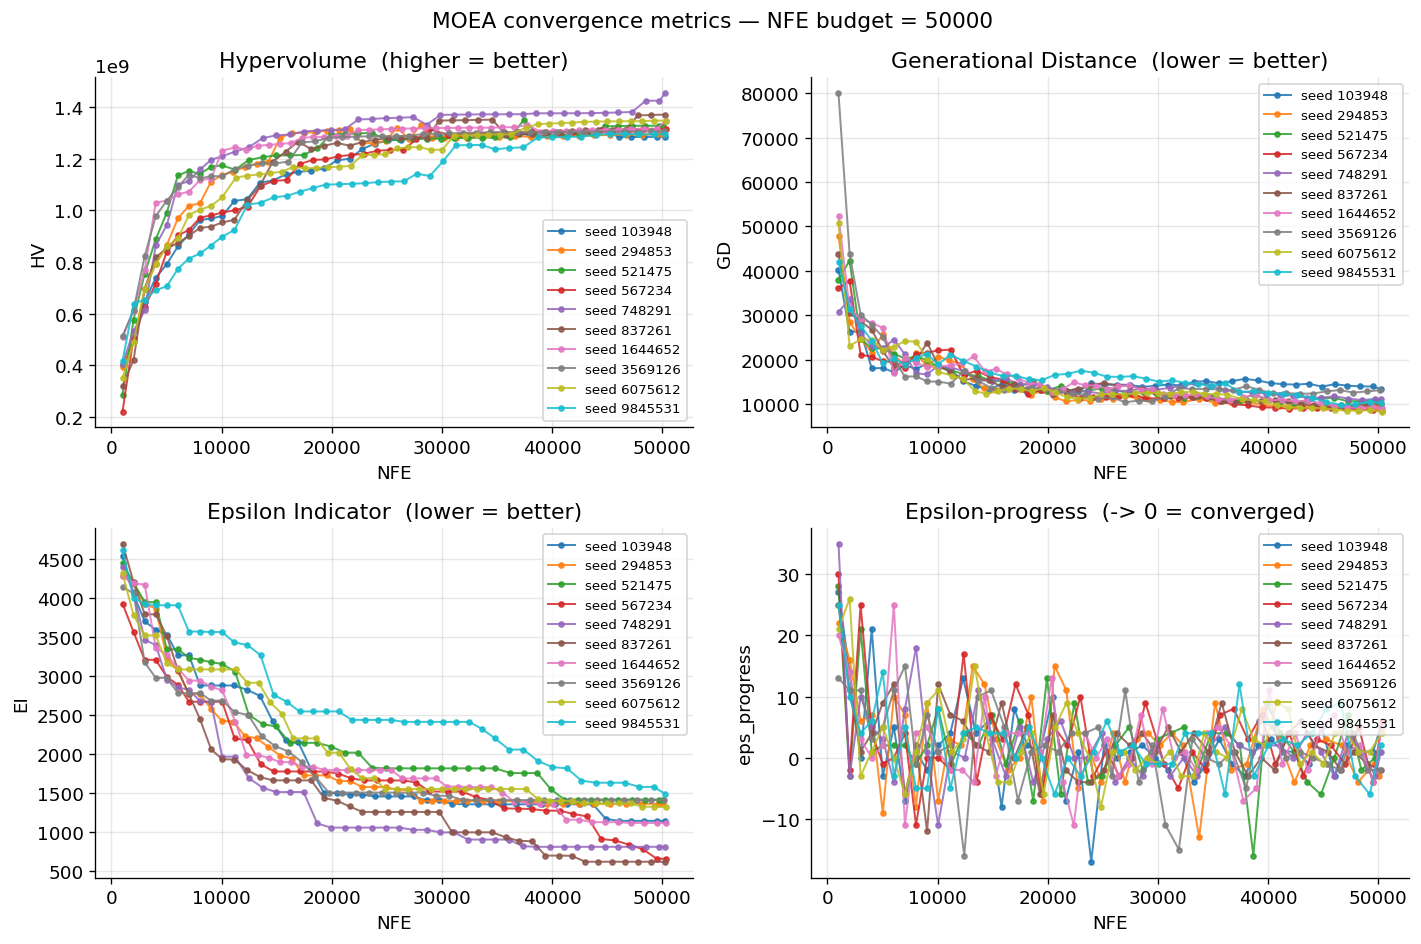

  saved: c:\Users\leahm\.vscode\EPA141\LDC_Group-\assignments_ema\results_big\convergence_metrics_PRIORITARIAN_50000.png


In [6]:
# --- YOUR TASK ---
# For each seed and NFE budget, compute Pareto front quality metrics
# at every archive snapshot and store the results 
#
# The snapshots are in all_snapshots — each entry contains the Pareto archive
# as it looked at a specific point during the optimisation run.
# By computing metrics at each snapshot you can track whether the algorithm
# converged before the NFE budget was exhausted.
#
# Sample metrics to compute:
#   - Hypervolume (HV)           — how much of the objective space is dominated
#   - Generational Distance (GD) — how close the archive is to the reference set
#   - Epsilon Indicator (EI)     — how much the reference set still dominates the archive
#   - Epsilon-progress (eps)     — how many new solutions were added at each checkpoint
#
#Store your results
#
# Hint: check the ema_workbench convergence metrics documentation and the
# _deap_hypervolume() function defined in the setup cell. 


# YOUR CODE HERE — compute metrics

# ── Visualisation ─────────────────────────────────────────────────────────────
# Create one figure per NFE budget with four panels, one per metric (HV, GD, EI, eps).
# Plot NFE on the x-axis and the metric value on the y-axis.
# Show all seeds on the same panel
#
# YOUR CODE HERE — plot
# Compute Hypervolume, Generational Distance, Epsilon Indicator, and
# epsilon-progress per (NFE budget, seed) at every archive snapshot.
#
# GD / EI are computed via the local _generational_distance and
# _epsilon_indicator helpers (defined in the setup cell). Same definitions
# as ema_workbench's Platypus-based metrics; just don't go through the
# broken rebuild_platypus_population path.

# metrics_records[(nfe, seed)] = DataFrame with columns [checkpoint_nfe, HV, GD, EI, eps_progress]
metrics_records = {}

for nfe, seed_dfs in nfe_groups.items():
    ref_df = reference_sets[nfe]
    ref_point = _compute_ref_point(ref_df, margin=0.1)

    for (n_budget, seed), snaps in all_snapshots.items():
        if n_budget != nfe:
            continue
        rows = []
        sorted_checkpoints = sorted(snaps.keys())
        prev_archive_size = 0
        for cp in sorted_checkpoints:
            snap = snaps[cp]
            if not all(c in snap.columns for c in OBJECTIVE_COLS):
                continue
            try:
                hv = _compute_hypervolume(snap, ref_point)
            except Exception:
                hv = np.nan
            try:
                gd = _generational_distance(snap, ref_df, OBJECTIVE_COLS, MAXIMIZE_COLS, p=1.0)
            except Exception:
                gd = np.nan
            try:
                ei = _epsilon_indicator(snap, ref_df, OBJECTIVE_COLS, MAXIMIZE_COLS)
            except Exception:
                ei = np.nan
            eps_progress = len(snap) - prev_archive_size
            prev_archive_size = len(snap)
            rows.append({
                "checkpoint_nfe": cp,
                "HV":             hv,
                "GD":             gd,
                "EI":             ei,
                "eps_progress":   eps_progress,
            })
        metrics_records[(nfe, seed)] = pd.DataFrame(rows).sort_values("checkpoint_nfe")
        print(f"  computed metrics for NFE={nfe} seed={seed} "
              f"({len(metrics_records[(nfe, seed)])} checkpoints)")

# ── Plot ──────────────────────────────────────────────────────────────────────
metric_specs = [
    ("HV",           "Hypervolume",          "higher = better"),
    ("GD",           "Generational Distance", "lower = better"),
    ("EI",           "Epsilon Indicator",     "lower = better"),
    ("eps_progress", "Epsilon-progress",      "-> 0 = converged"),
]

for nfe in sorted(nfe_groups):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for ax, (col, title, hint) in zip(axes, metric_specs):
        for (n_budget, seed), df_m in metrics_records.items():
            if n_budget != nfe:
                continue
            ax.plot(df_m["checkpoint_nfe"], df_m[col], marker="o",
                    markersize=3, linewidth=1.2, alpha=0.85, label=f"seed {seed}")
        ax.set_title(f"{title}  ({hint})")
        ax.set_xlabel("NFE")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f"MOEA convergence metrics — NFE budget = {nfe}", fontsize=13)
    plt.tight_layout()
    out_png = os.path.join(RESULTS_ROOT, f"convergence_metrics_{WF_NAME}_{nfe}.png")
    plt.savefig(out_png, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  saved: {out_png}")


Interpret the plots
>your answer here


---

## Reflection Questions

**1. Hypervolume convergence.** Does the hypervolume plateau before the NFE budget is exhausted, or is it still growing? What change to the optimisation setup would you recommend if HV was still rising at the final NFE?

**2. Epsilon-progress.** At what approximate NFE does epsilon-progress first reach zero (or near-zero)? Is this consistent with what you see in the hypervolume curve? Explain.

**3. Seed consistency.** If multiple seeds produce very different final hypervolumes within the same NFE group, what does that suggest about (a) the landscape of the objective space, and (b) the reliability of any single seed as a representative Pareto front?
